In [13]:
import os
import torch

# load all environment variables from .env file
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Keys

In [14]:
BASE_DIR = os.getenv("BASE_DIR", ".")

inputs = torch.load(
    os.path.join(BASE_DIR, "model_inputs.pt"), weights_only=False
)
outputs = torch.load(
    os.path.join(BASE_DIR, "model_outputs.pt"), weights_only=False
)

print(inputs.keys())
print(outputs.keys())

dict_keys(['input_ids', 'labels'])
dict_keys(['loss', 'logits', 'past_key_values'])


In [15]:
outputs['past_key_values'].layers[0].keys.shape

torch.Size([4, 8, 1024, 64])

In [16]:
pkv = outputs['past_key_values']  # Expect a DynamicCache object

# retrieve all keys into a single tensor of shape (B, L, H, T, head_dim) - B=batch size, L=number of layers, H=number of heads, T=sequence length, head_dim=head dimension
all_keys = []
for layer_idx, layer_cache in enumerate(pkv.layers):
    all_keys.append(layer_cache.keys)

keys = torch.stack(all_keys, dim=1)  # shape (B, L, H, T, head_dim)
print("All keys tensor shape:", keys.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
keys = keys.to(device)

All keys tensor shape: torch.Size([4, 16, 8, 1024, 64])


# Get Suprise-based event boundaries

In [17]:
def find_thresholds(surprise, window=100, threshold_param=3.0, min_size=0, fixed_prob=None):

    events_sur = []
    if fixed_prob is None:
        threshold = torch.zeros(len(surprise))
        for t in range(len(surprise)):
            if 0 < t <= window:
                threshold[t] = torch.mean(surprise[:t]) + torch.std(surprise[:t])*threshold_param
            elif t > window:
                threshold[t] = torch.mean(surprise[t-window:t]) + torch.std(surprise[t-window:t])*threshold_param
            else:
                threshold[t] = surprise[t]  # For t == 0
    else:
        threshold = torch.full((len(surprise),),-torch.log(torch.tensor(fixed_prob)))
        threshold[0] = surprise[0]

    for t in range(len(surprise)):
        if surprise[t] >= threshold[t]:
            if len(events_sur) == 0:
                events_sur.append(t)
            elif t - events_sur[-1] >= min_size:
                events_sur.append(t)
    # Append last timestep as a border
    if events_sur[-1] != t:
        events_sur.append(t)

    
    print('The threshold found',len(events_sur),'events including borders.')
    return events_sur, threshold

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

labels = inputs['labels'].to(device)
logits = outputs['logits'].to(device)

prob = torch.softmax(logits, dim = -1)
surprisal = -torch.log(torch.gather(prob, dim=-1, index=labels.unsqueeze(-1))).squeeze(-1)
print(surprisal.shape)

events, _ = find_thresholds(surprisal[0])
print(events)

torch.Size([4, 1024])
The threshold found 17 events including borders.
[0, 4, 14, 219, 346, 381, 421, 432, 485, 534, 668, 677, 707, 839, 855, 942, 1023]


/tmp/ipykernel_11332/294465397.py:8: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  threshold[t] = torch.mean(surprise[:t]) + torch.std(surprise[:t])*threshold_param


# Metrics

In [19]:
def mse(a, b):
    return ((a - b) ** 2).mean()

def abs_error(a, b):
    return (a - b).abs().sum(dim=(-1,-2)).mean()

def relative_error(a, b):
    return ((a - b).abs().sum() / a.abs().sum().clamp(min=1e-12))

def compute_svd_error(A, U, S, V, error_fn):
    # Reconstruct A from U, S, V
    A_reconstructed = (U * S.unsqueeze(-2)) @ V
    return error_fn(A, A_reconstructed)

def compression_ratio(A, U, V):
    original_size = A.numel()
    compressed_size = U.numel() + V.numel()
    return original_size / compressed_size

def print_all_errors(A, U, S, V):
    print("MSE:", compute_svd_error(A, U, S, V, mse).item())
    print("Absolute Error:", compute_svd_error(A, U, S, V, abs_error).item())
    print("Relative Error:", compute_svd_error(A, U, S, V, relative_error).item())
    print("Compression Ratio:", compression_ratio(A, U, V))

# Singular Values Analysis

In [28]:
def calc_energy(M):
    S = torch.linalg.svdvals(M)  # (d,)
    cumsum = (S**2).cumsum(-1)
    return (S**2).cumsum(-1) / (S**2).sum(-1, keepdim=True)

In [ ]:
energy = calc_energy(keys.float())

torch.Size([4, 16, 8, 64])

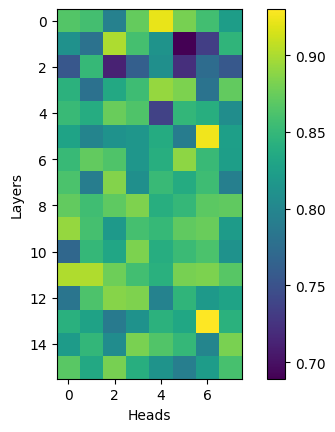

In [35]:
import matplotlib.pyplot as plt

def plot_energy_at_rank_k(energy, k):
    energy = energy.clone()
    if energy.dim() > 3:
        energy = energy.mean(0)  # average over batch size
    energy = energy[..., k]

    # plot a heatmap of the energies
    plt.imshow(energy.cpu().numpy())
    plt.colorbar()
    plt.xlabel("Heads")
    plt.ylabel("Layers")
    plt.show()

plot_energy_at_rank_k(energy, 16)

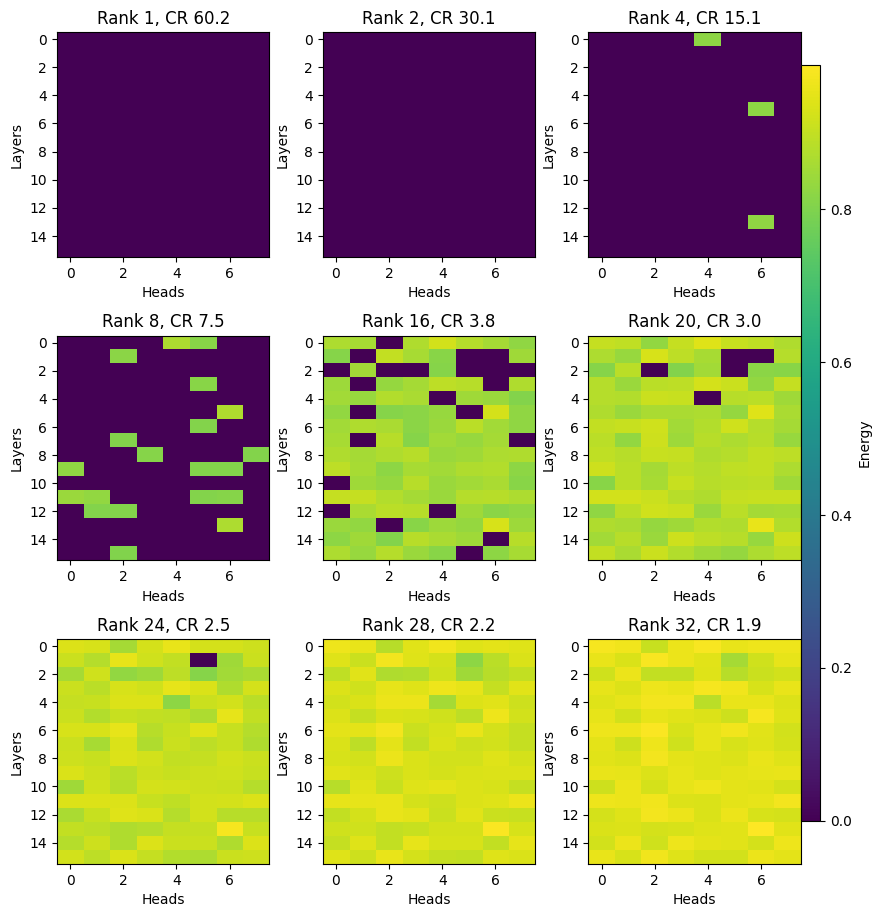

In [56]:
import matplotlib.pyplot as plt
import math
import torch

def plot_energy_at_ranks(
    energy,
    ranks,
    comp_ratios,
    energy_threshold=None,
    ncols=None,
    figsize_per_plot=(3.2, 3.6),
    cmap="viridis",
):
    energy = energy.clone()
    if energy.dim() > 3:
        energy = energy.mean(0)

    if energy_threshold is not None:
        energy = energy.masked_fill(energy < energy_threshold, 0.0)

    n = len(ranks)
    if ncols is None:
        ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    # --- compute shared color scale ---
    stacked = torch.stack([energy[..., k] for k in ranks])
    vmin = stacked.min().item()
    vmax = stacked.max().item()

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols,
                 figsize_per_plot[1] * nrows),
        squeeze=False,
    )

    ims = []
    for ax, (i, k) in zip(axes.flat, enumerate(ranks)):
        im = ax.imshow(
            energy[..., k].cpu().numpy(),
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            aspect="auto",
        )
        ims.append(im)
        ax.set_title(f"Rank {k}, CR {comp_ratios[i]:.1f}")
        ax.set_xlabel("Heads")
        ax.set_ylabel("Layers")

    for ax in axes.flat[n:]:
        ax.axis("off")

    # --- single shared colorbar ---
    # create dedicated colorbar axis (outside the grid)
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

    fig.subplots_adjust(
        wspace=0.25,   # horizontal gap
        hspace=0.35,   # vertical gap
    )

    cbar = fig.colorbar(ims[0], cax=cax)
    cbar.set_label("Energy")

    plt.show()


ranks = [1,2,4,8,16,20,24,28,32]
m,n = keys.shape[-2:]
comp_ratios = [(m*n)/(m*k + k*n) for k in ranks]
plot_energy_at_ranks(
    energy,
    ranks,
    comp_ratios,
    energy_threshold=0.8,
)

# SVD

### Truncated SVD

In [91]:
from utils import full_svd, truncated_svd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
full_svd_keys = full_svd(keys)
print(" ===== Errors for full SVD:")
print_all_errors(keys, *full_svd_keys)

U, S, V = full_svd_keys
pred = (U * S.unsqueeze(-2)) @ V
rel_errors = (keys - pred).abs().sum(dim=(-1,-2)) / keys.abs().sum(dim=(-1,-2))

print("Maximum relative error: ", torch.max(rel_errors))
print("Minimum relative error: ", torch.min(rel_errors))

 ===== Errors for full SVD:
MSE: 7.772445678710938e-05
Absolute Error: 290.0
Relative Error: 0.0025634765625
Compression Ratio: 0.9411764705882353
Maximum relative error:  tensor(0.0035, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.0020, device='cuda:0', dtype=torch.bfloat16)


In [ ]:
full_svd_keys = truncated_svd(keys, 32)
print(" ===== Errors for full SVD:")
print_all_errors(keys, *full_svd_keys)

U, S, V = full_svd_keys
pred = (U * S.unsqueeze(-2)) @ V
rel_errors = (keys - pred).abs().sum(dim=(-1,-2)) / keys.abs().sum(dim=(-1,-2))

print("Maximum relative error: ", torch.max(rel_errors))
print("Minimum relative error: ", torch.min(rel_errors))

 ===== Errors for full SVD:
MSE: 0.36328125
Absolute Error: 28160.0
Relative Error: 0.2490234375
Compression Ratio: 1.8823529411764706
Maximum relative error:  tensor(0.3770, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.1128, device='cuda:0', dtype=torch.bfloat16)


#### random chunks

In [118]:
for _ in range(10):
    chunk_size = 64
    st = torch.randint(8, keys.size(-2) - chunk_size, (1,))
    ed = min(st + chunk_size, keys.size(-2))
    keys_subset = keys[..., st:ed, :]

    full_svd_keys = truncated_svd(keys_subset, 16)
    print(" ===== Errors for full SVD:")
    print_all_errors(keys_subset, *full_svd_keys)

    U, S, V = full_svd_keys
    pred = (U * S.unsqueeze(-2)) @ V
    rel_errors = (keys_subset - pred).abs().sum(dim=(-1,-2)) / keys_subset.abs().sum(dim=(-1,-2))

    print("Maximum relative error: ", torch.max(rel_errors))
    print("Minimum relative error: ", torch.min(rel_errors))

 ===== Errors for full SVD:
MSE: 0.265625
Absolute Error: 1600.0
Relative Error: 0.22265625
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3340, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.1396, device='cuda:0', dtype=torch.bfloat16)
 ===== Errors for full SVD:
MSE: 0.267578125
Absolute Error: 1608.0
Relative Error: 0.236328125
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3418, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.1436, device='cuda:0', dtype=torch.bfloat16)
 ===== Errors for full SVD:
MSE: 0.259765625
Absolute Error: 1584.0
Relative Error: 0.224609375
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3340, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.1406, device='cuda:0', dtype=torch.bfloat16)
 ===== Errors for full SVD:
MSE: 0.265625
Absolute Error: 1600.0
Relative Error: 0.22265625
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3438, device='cuda:0', d

#### suprise-segmented chunks

In [131]:
print(events)

[0, 4, 14, 219, 346, 381, 421, 432, 485, 534, 668, 677, 707, 839, 855, 942, 1023]


In [133]:
for i, st in enumerate(events[:-1]):
    ed = events[i+1]
    keys_subset = keys[..., st:ed, :]
    event_size = ed-st
    rank = min(16, event_size//2)
    full_svd_keys = truncated_svd(keys_subset, rank)
    print(" ===== Errors for full SVD:")
    print_all_errors(keys_subset, *full_svd_keys)

    U, S, V = full_svd_keys
    pred = (U * S.unsqueeze(-2)) @ V
    rel_errors = (keys_subset - pred).abs().sum(dim=(-1,-2)) / keys_subset.abs().sum(dim=(-1,-2))

    print("Maximum relative error: ", torch.max(rel_errors))
    print("Minimum relative error: ", torch.min(rel_errors))

 ===== Errors for full SVD:
MSE: 0.1640625
Absolute Error: 69.0
Relative Error: 0.2333984375
Compression Ratio: 1.8823529411764706
Maximum relative error:  tensor(0.4043, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.1309, device='cuda:0', dtype=torch.bfloat16)
 ===== Errors for full SVD:
MSE: 0.203125
Absolute Error: 212.0
Relative Error: 0.216796875
Compression Ratio: 1.7297297297297298
Maximum relative error:  tensor(0.3066, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.1187, device='cuda:0', dtype=torch.bfloat16)
 ===== Errors for full SVD:
MSE: 0.58203125
Absolute Error: 7552.0
Relative Error: 0.34765625
Compression Ratio: 3.0483271375464684
Maximum relative error:  tensor(0.4688, device='cuda:0', dtype=torch.bfloat16)
Minimum relative error:  tensor(0.2363, device='cuda:0', dtype=torch.bfloat16)
 ===== Errors for full SVD:
MSE: 0.458984375
Absolute Error: 4160.0
Relative Error: 0.296875
Compression Ratio: 2.6596858638743455
Ma

#### Ablate ranks

In [93]:
truncated_svd_keys = {}
ranks = list(range(1, keys.shape[-1] + 1))
for rank in ranks:
    truncated_svd_keys[rank] = {'trunc_keys': truncated_svd(keys, rank)}
    truncated_svd_keys[rank]['relative_err'] = compute_svd_error(
        keys, *(truncated_svd_keys[rank]['trunc_keys']), relative_error
    ).item()
    truncated_svd_keys[rank]['compression_ratio'] = compression_ratio(
        keys,
        truncated_svd_keys[rank]['trunc_keys'][0],
        truncated_svd_keys[rank]['trunc_keys'][-1]
    )


Intercept found at rank  30
Error at intercept:  0.26953125


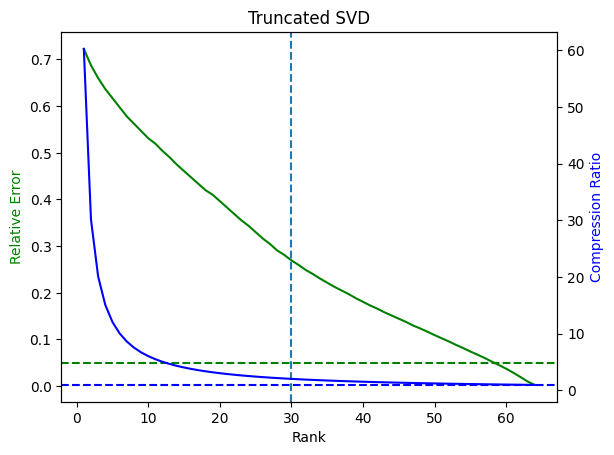

In [102]:
import matplotlib.pyplot as plt

for i, comp_ratio in enumerate([truncated_svd_keys[rank]['compression_ratio'] for rank in ranks]):
    if comp_ratio < 2.0:
        intercept = i
        print("Intercept found at rank ", intercept)
        print("Error at intercept: ", truncated_svd_keys[intercept]['relative_err'])
        break

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(
    ranks, 
    [truncated_svd_keys[rank]['relative_err'] for rank in ranks], 
    'g-', label='Relative Error'
)
ax2.plot(
    ranks, 
    [truncated_svd_keys[rank]['compression_ratio'] for rank in ranks], 
    'b-',
    label='Compression Ratio'
)
ax1.set_xlabel('Rank')
ax1.set_ylabel('Relative Error', color='g')
# make horizontal line at 0.05
ax1.axhline(y=0.05, color='g', linestyle='--')
ax1.axvline(x=intercept, linestyle='--')
ax2.set_ylabel('Compression Ratio', color='b')
# make horizontal line at 1.0
ax2.axhline(y=1.0, color='b', linestyle='--')
plt.title('Truncated SVD')
plt.show()

### Repeat per-layer

In [ ]:
from tqdm import tqdm

truncated_svd_keys_per_layer = {}
ranks = list(range(1, keys.shape[-1] + 1))
for layer in tqdm(range(keys.size(1))):
    layer_keys = keys[:, : ,layer, ...]
    truncated_svd_keys_per_layer[layer] = {}
    for rank in ranks:
        truncated_svd_keys_per_layer[layer][rank] = {'trunc_keys': truncated_svd(layer_keys, rank)}
        truncated_svd_keys_per_layer[layer][rank]['relative_err'] = compute_svd_error(
            layer_keys, *(truncated_svd_keys_per_layer[layer][rank]['trunc_keys']), relative_error
        ).item()
        truncated_svd_keys_per_layer[layer][rank]['compression_ratio'] = compression_ratio(
            layer_keys,
            truncated_svd_keys_per_layer[layer][rank]['trunc_keys'][0],
            truncated_svd_keys_per_layer[layer][rank]['trunc_keys'][-1]
        )

100%|██████████| 16/16 [01:00<00:00,  3.78s/it]


Intercept found at rank  30
Error at intercept:  0.21484375


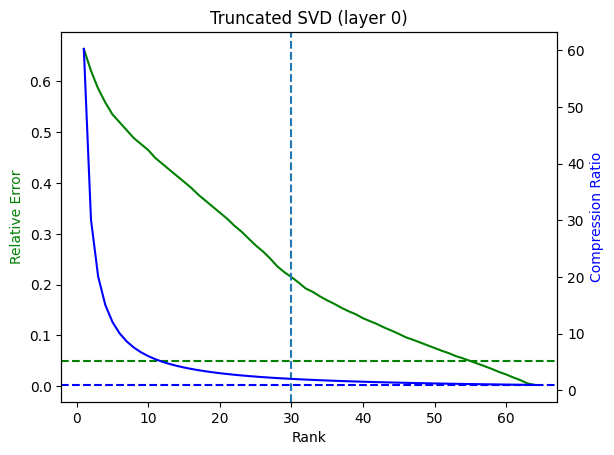

Intercept found at rank  30
Error at intercept:  0.263671875


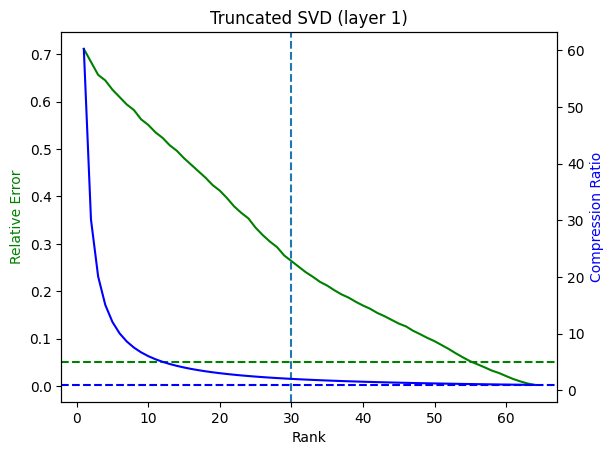

Intercept found at rank  30
Error at intercept:  0.314453125


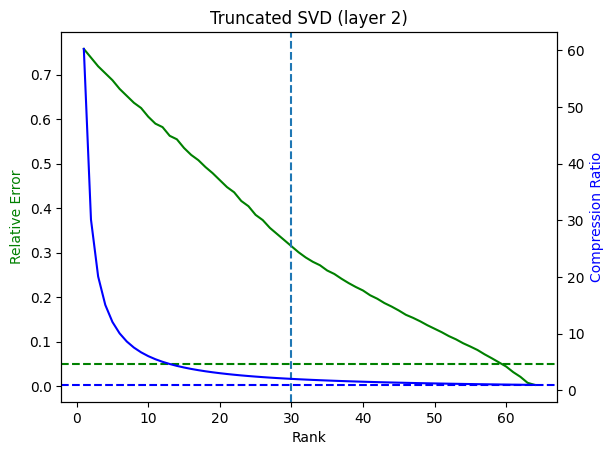

Intercept found at rank  30
Error at intercept:  0.244140625


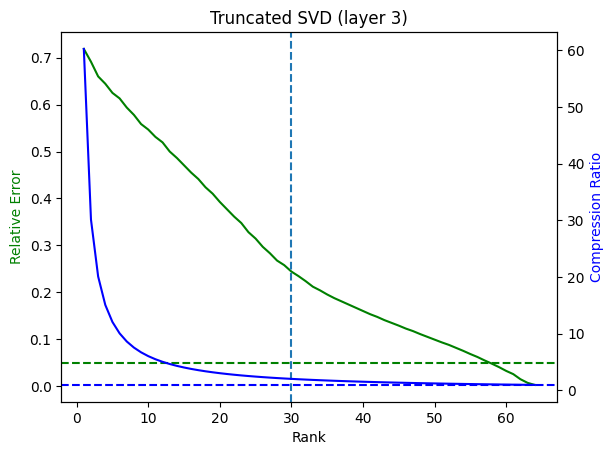

Intercept found at rank  30
Error at intercept:  0.267578125


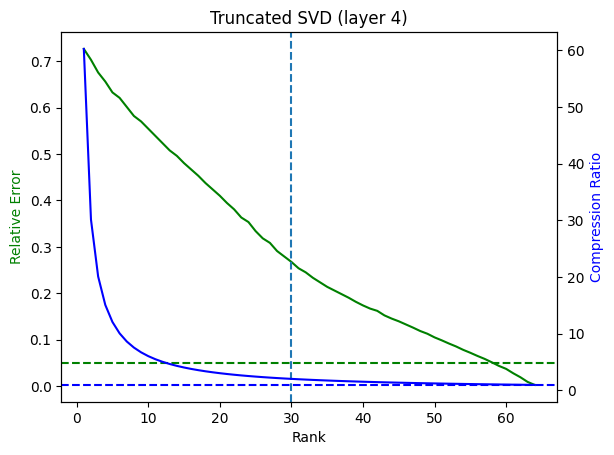

Intercept found at rank  30
Error at intercept:  0.279296875


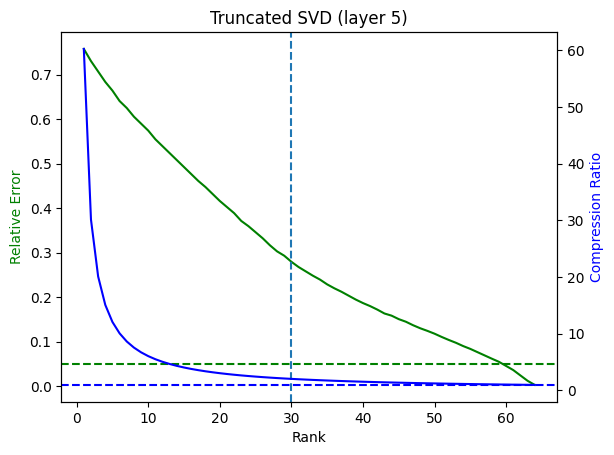

Intercept found at rank  30
Error at intercept:  0.259765625


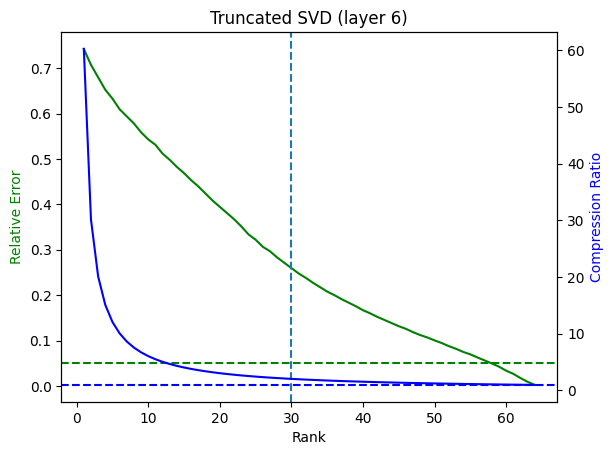

Intercept found at rank  30
Error at intercept:  0.294921875


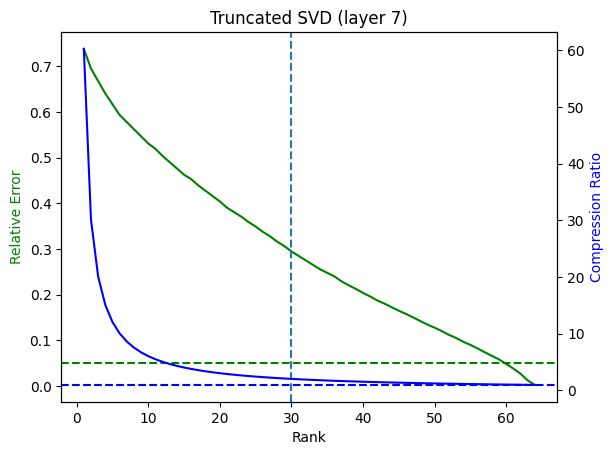

Intercept found at rank  30
Error at intercept:  0.271484375


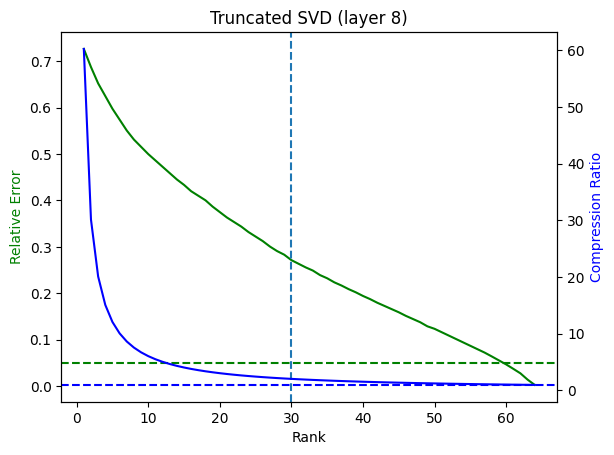

Intercept found at rank  30
Error at intercept:  0.263671875


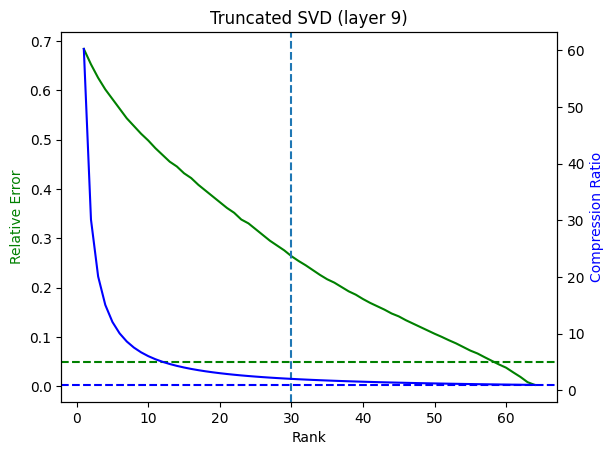

Intercept found at rank  30
Error at intercept:  0.275390625


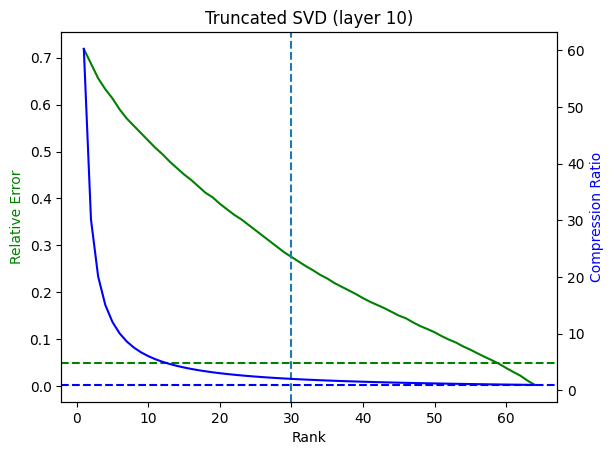

Intercept found at rank  30
Error at intercept:  0.2578125


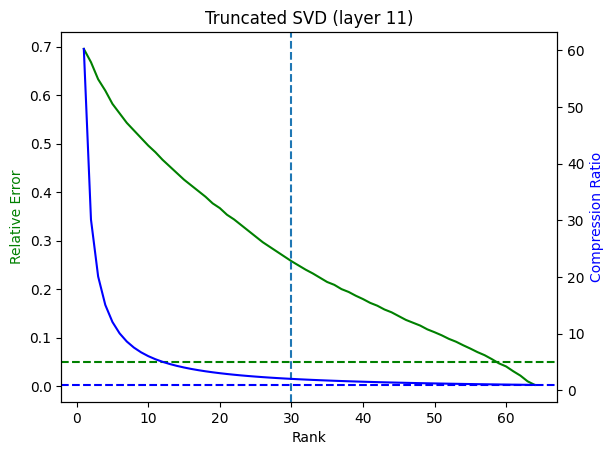

Intercept found at rank  30
Error at intercept:  0.27734375


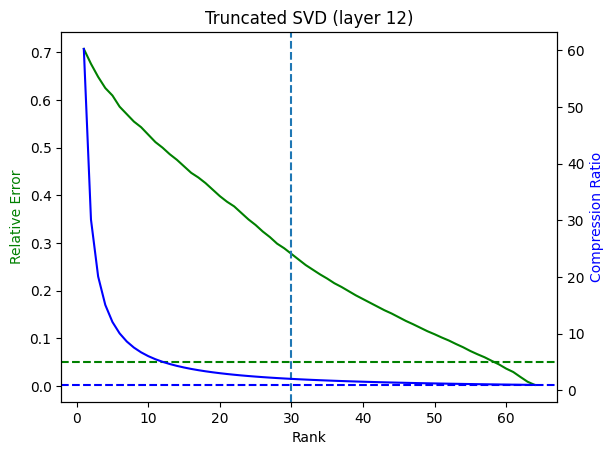

Intercept found at rank  30
Error at intercept:  0.26953125


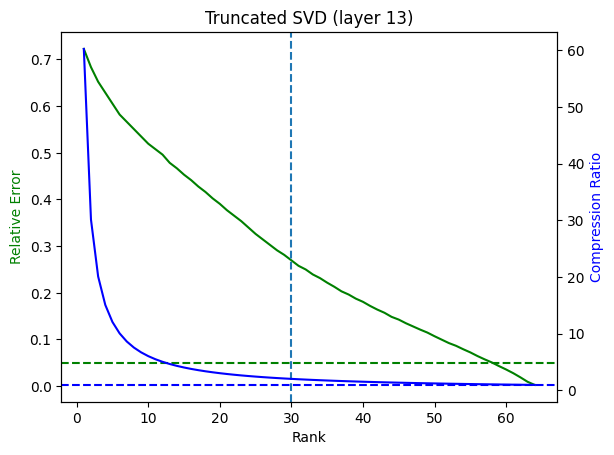

Intercept found at rank  30
Error at intercept:  0.275390625


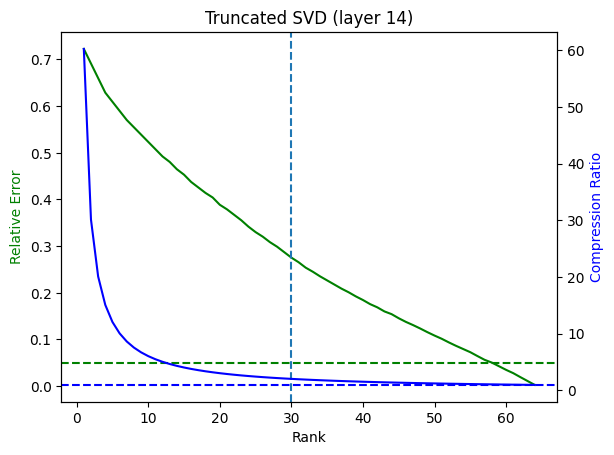

Intercept found at rank  30
Error at intercept:  0.275390625


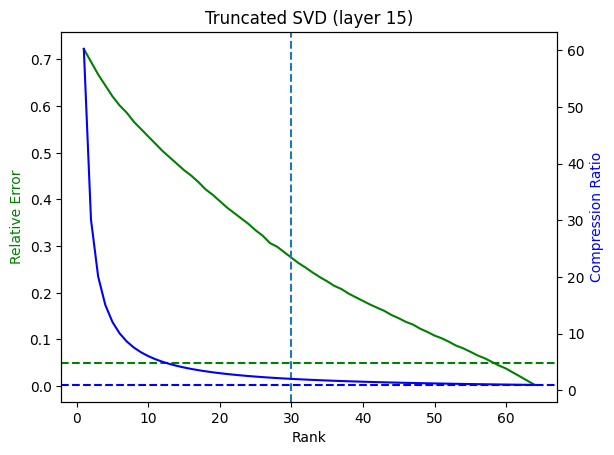

In [ ]:
import matplotlib.pyplot as plt

for layer in range(keys.size(1)):
    for i, comp_ratio in enumerate([truncated_svd_keys_per_layer[layer][rank]['compression_ratio'] for rank in ranks]):
        if comp_ratio < 2.0:
            intercept = i
            print("Intercept found at rank ", intercept)
            print("Error at intercept: ", truncated_svd_keys_per_layer[layer][intercept]['relative_err'])
            break

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(
        ranks, 
        [truncated_svd_keys_per_layer[layer][rank]['relative_err'] for rank in ranks], 
        'g-', label='Relative Error'
    )
    ax2.plot(
        ranks, 
        [truncated_svd_keys_per_layer[layer][rank]['compression_ratio'] for rank in ranks], 
        'b-',
        label='Compression Ratio'
    )
    ax1.set_xlabel('Rank')
    ax1.set_ylabel('Relative Error', color='g')
    # make horizontal line at 0.05
    ax1.axhline(y=0.05, color='g', linestyle='--')
    ax1.axvline(x=intercept, linestyle='--')
    ax2.set_ylabel('Compression Ratio', color='b')
    # make horizontal line at 1.0
    ax2.axhline(y=1.0, color='b', linestyle='--')
    plt.title(f'Truncated SVD (layer {layer})')
    plt.show()

# Learned LoRA

In [95]:
from utils import learn_lora_matrix

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [96]:
def print_all_lora_errors(M, A, B):
    pred = A @ B
    print("MSE:", mse(M, pred).item())
    print("Absolute Error:", abs_error(M, pred).item())
    print("Relative Error:", relative_error(M, pred).item())
    print("Compression Ratio:", compression_ratio(M, A, B))

MSE: 0.3497558832168579
Absolute Error: 27279.03125
Relative Error: 0.2410830706357956
Compression Ratio: 1.8823529411764706
Maximum relative error:  tensor(0.3617, device='cuda:0')
Minimum relative error:  tensor(0.1211, device='cuda:0')


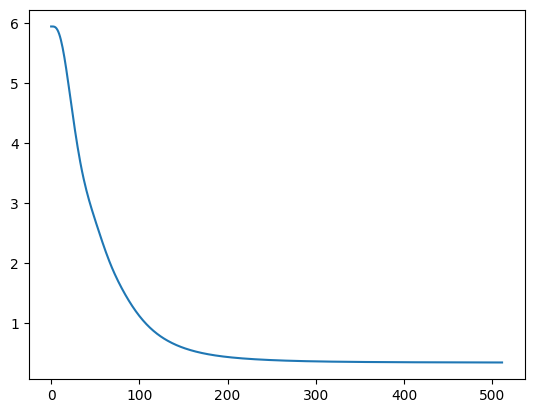

In [112]:
k = 32
A, B, losses = learn_lora_matrix(keys.float(), k, n_iter=512, lr=1e-2, std=0.1)
print_all_lora_errors(keys, A, B)

pred = A @ B
rel_errors = (keys - pred).abs().sum(dim=(-1,-2)) / keys.abs().sum(dim=(-1,-2))

print("Maximum relative error: ", torch.max(rel_errors))
print("Minimum relative error: ", torch.min(rel_errors))

plt.plot(losses)

In [120]:
for _ in range(10):
    chunk_size = 64
    st = torch.randint(8, keys.size(-2) - chunk_size, (1,))
    ed = min(st + chunk_size, keys.size(-2))
    keys_subset = keys[..., st:ed, :]

    k = 16
    A, B, losses = learn_lora_matrix(keys_subset.float(), k, n_iter=512, lr=1e-2, std=0.1)
    print_all_lora_errors(keys_subset, A, B)

    pred = A @ B
    rel_errors = (keys_subset - pred).abs().sum(dim=(-1,-2)) / keys_subset.abs().sum(dim=(-1,-2))

    print("Maximum relative error: ", torch.max(rel_errors))
    print("Minimum relative error: ", torch.min(rel_errors))

MSE: 0.2619289755821228
Absolute Error: 1591.8876953125
Relative Error: 0.22208254039287567
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3173, device='cuda:0')
Minimum relative error:  tensor(0.1427, device='cuda:0')
MSE: 0.26775217056274414
Absolute Error: 1609.7271728515625
Relative Error: 0.22258394956588745
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3339, device='cuda:0')
Minimum relative error:  tensor(0.1394, device='cuda:0')
MSE: 0.2560338079929352
Absolute Error: 1569.677490234375
Relative Error: 0.2180107682943344
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3194, device='cuda:0')
Minimum relative error:  tensor(0.1445, device='cuda:0')
MSE: 0.2654768228530884
Absolute Error: 1601.838134765625
Relative Error: 0.22753383219242096
Compression Ratio: 2.0
Maximum relative error:  tensor(0.3307, device='cuda:0')
Minimum relative error:  tensor(0.1420, device='cuda:0')
MSE: 0.26848718523979187
Absolute Error: 1611.94384765625
Relative Error: 0.2

In [ ]:
from tqdm import tqdm

lora_keys = {}
ranks = list(range(1, keys.shape[-1] + 1))
for rank in tqdm(ranks):
    A, B, _ = learn_lora_matrix(keys.float(), rank, n_iter=256, lr=1e-1, std=0.1)
    lora_keys[rank] = {
        'A': A, 'B': B,
        'relative_err': relative_error(keys, A @ B).item(),
        'compression_ratio': compression_ratio(keys, A, B)
    }

100%|██████████| 64/64 [01:45<00:00,  1.64s/it]


Intercept found at rank  30
Error at intercept:  0.25913116335868835


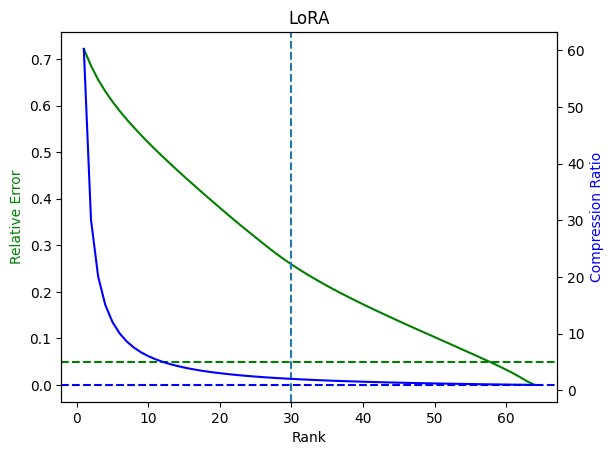

In [101]:
import matplotlib.pyplot as plt

for i, comp_ratio in enumerate([lora_keys[rank]['compression_ratio'] for rank in ranks]):
    if comp_ratio < 2.0:
        intercept = i
        print("Intercept found at rank ", intercept)
        print("Error at intercept: ", lora_keys[intercept]['relative_err'])
        break

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(
    ranks, 
    [lora_keys[rank]['relative_err'] for rank in ranks], 
    'g-', label='Relative Error'
)
ax2.plot(
    ranks, 
    [lora_keys[rank]['compression_ratio'] for rank in ranks], 
    'b-',
    label='Compression Ratio'
)
ax1.set_xlabel('Rank')
ax1.set_ylabel('Relative Error', color='g')
# make horizontal line at 0.05
ax1.axhline(y=0.05, color='g', linestyle='--')
ax1.axvline(x=intercept, linestyle='--')
ax2.set_ylabel('Compression Ratio', color='b')
# make horizontal line at 1.0
ax2.axhline(y=1.0, color='b', linestyle='--')
plt.title('LoRA')
plt.show()

### Repeat per-layer

In [ ]:
from tqdm import tqdm

lora_keys_per_layer = {}
ranks = list(range(1, keys.shape[-1] + 1))
for layer in tqdm(range(keys.size(1))):
    layer_keys = keys[:, : ,layer, ...]
    lora_keys_per_layer[layer] = {}
    for rank in tqdm(ranks):
        A, B, _ = learn_lora_matrix(
            layer_keys.float(), rank, n_iter=256, lr=1e-1, std=0.1
        )
        lora_keys_per_layer[layer][rank] = {
            'A': A, 'B': B,
            'relative_err': relative_error(layer_keys, A @ B).item(),
            'compression_ratio': compression_ratio(layer_keys, A, B)
        }

100%|██████████| 16/16 [04:25<00:00, 16.57s/it]


  0%|          | 0/16 [00:00<?, ?it/s]

Intercept found at rank  30
Error at intercept:  0.20187287032604218


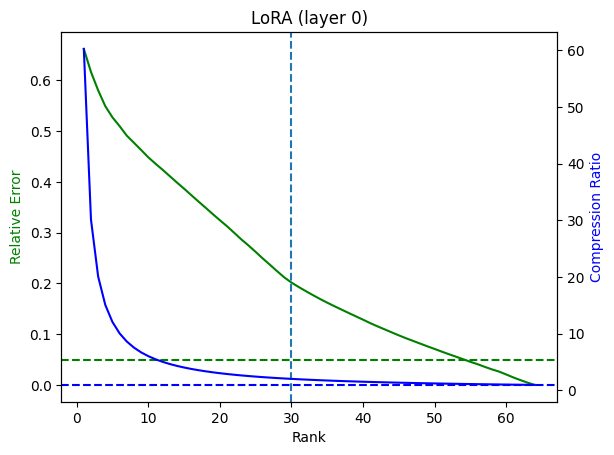

  6%|▋         | 1/16 [00:00<00:02,  7.04it/s]

Intercept found at rank  30
Error at intercept:  0.25032782554626465


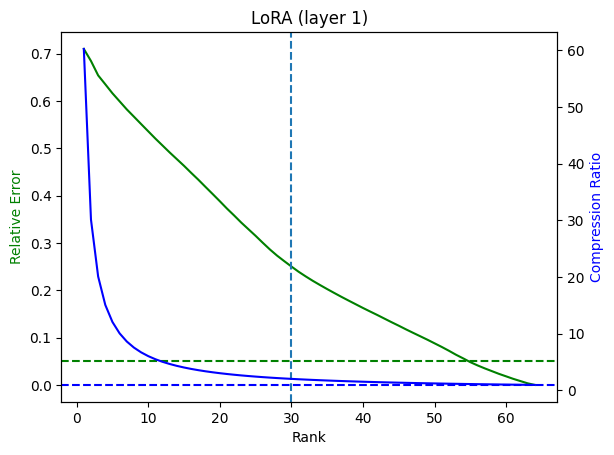

 12%|█▎        | 2/16 [00:00<00:01,  7.05it/s]

Intercept found at rank  30
Error at intercept:  0.29922953248023987


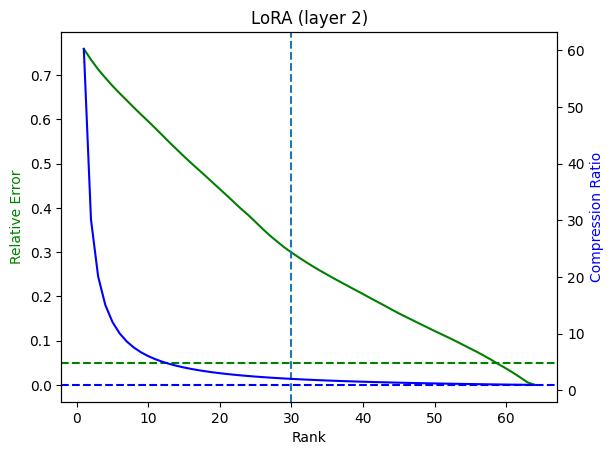

 19%|█▉        | 3/16 [00:00<00:01,  7.05it/s]

Intercept found at rank  30
Error at intercept:  0.23318010568618774


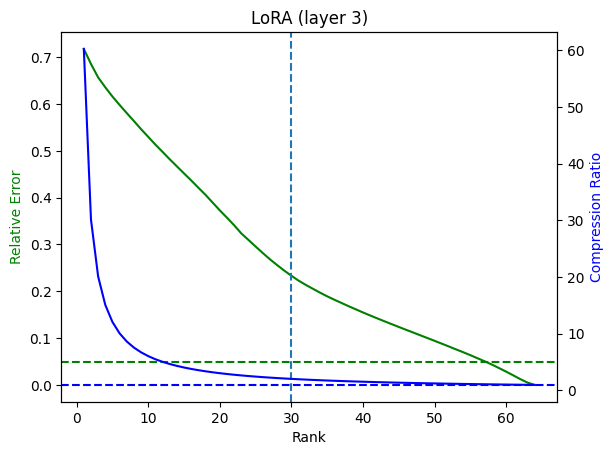

 25%|██▌       | 4/16 [00:00<00:01,  7.07it/s]

Intercept found at rank  30
Error at intercept:  0.25489842891693115


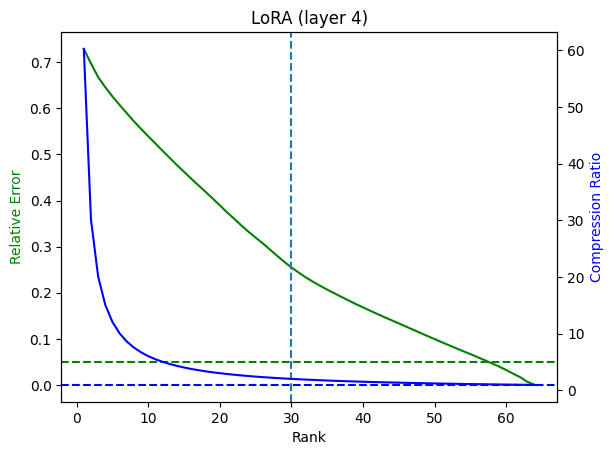

 31%|███▏      | 5/16 [00:00<00:01,  7.08it/s]

Intercept found at rank  30
Error at intercept:  0.26840561628341675


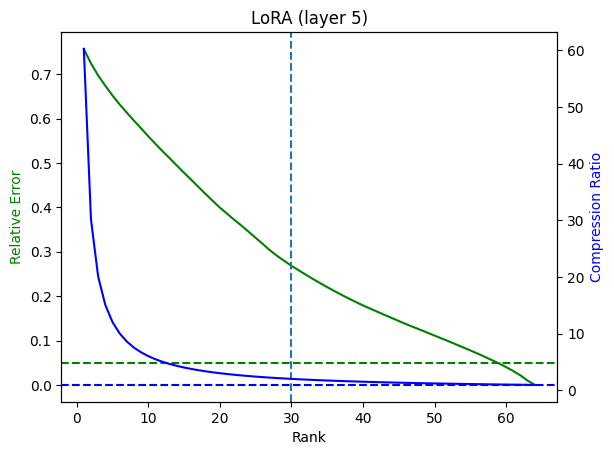

 38%|███▊      | 6/16 [00:00<00:01,  7.06it/s]

Intercept found at rank  30
Error at intercept:  0.24866518378257751


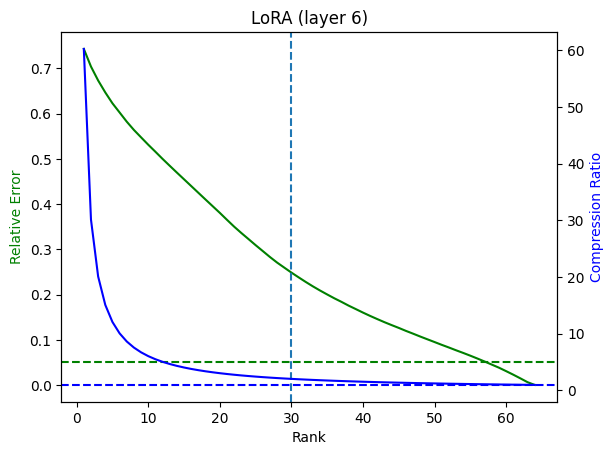

 44%|████▍     | 7/16 [00:01<00:01,  6.90it/s]

Intercept found at rank  30
Error at intercept:  0.2848774492740631


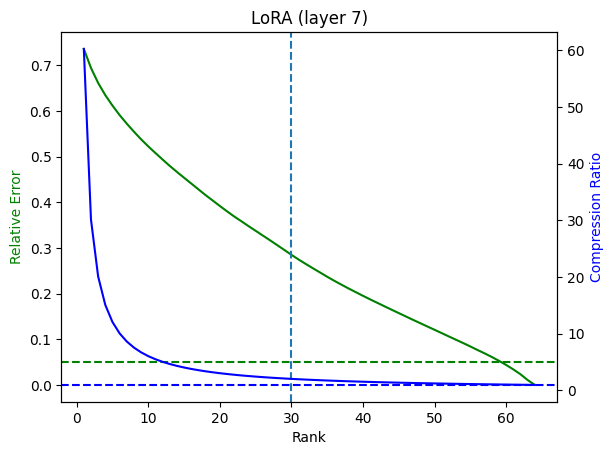

 50%|█████     | 8/16 [00:01<00:01,  6.78it/s]

Intercept found at rank  30
Error at intercept:  0.2638576924800873


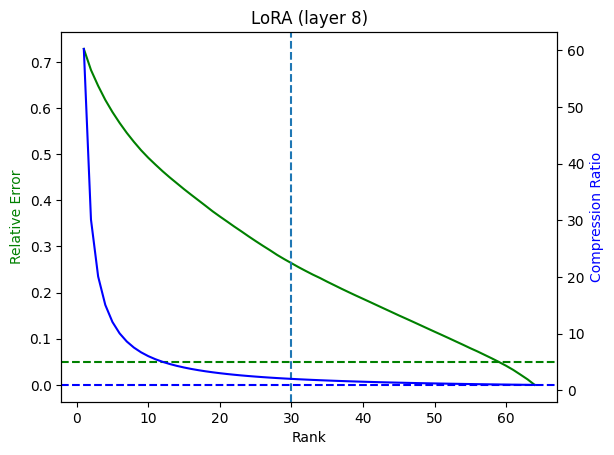

 56%|█████▋    | 9/16 [00:01<00:01,  6.88it/s]

Intercept found at rank  30
Error at intercept:  0.2536807656288147


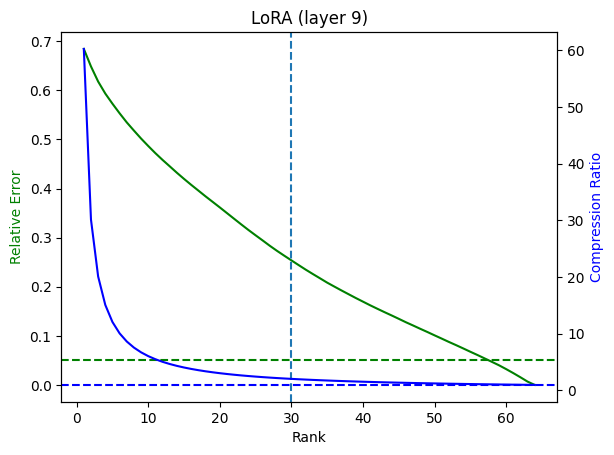

 62%|██████▎   | 10/16 [00:01<00:00,  6.92it/s]

Intercept found at rank  30
Error at intercept:  0.26630324125289917


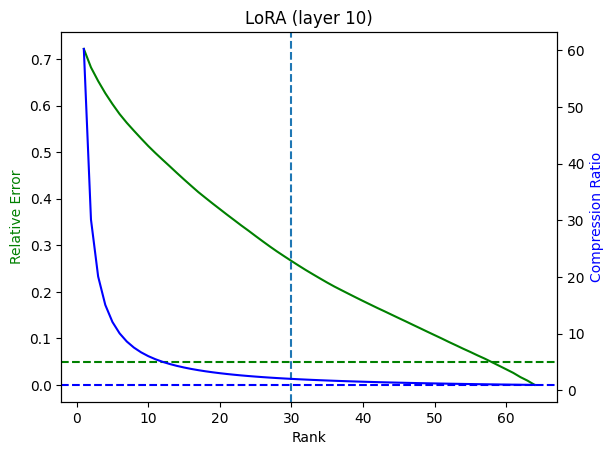

 69%|██████▉   | 11/16 [00:01<00:00,  6.93it/s]

Intercept found at rank  30
Error at intercept:  0.2492390275001526


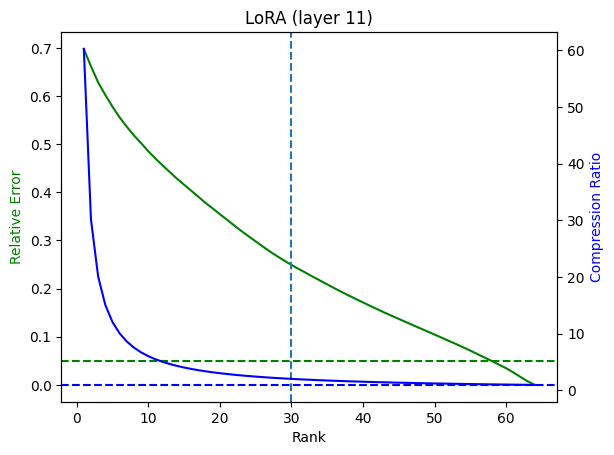

 75%|███████▌  | 12/16 [00:01<00:00,  6.97it/s]

Intercept found at rank  30
Error at intercept:  0.2654516100883484


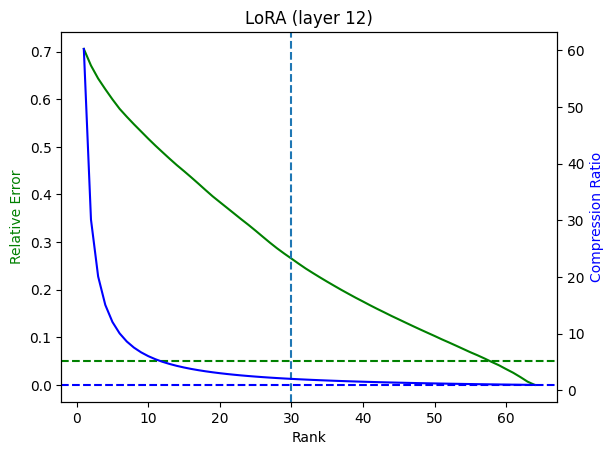

 81%|████████▏ | 13/16 [00:01<00:00,  6.99it/s]

Intercept found at rank  30
Error at intercept:  0.2587893009185791


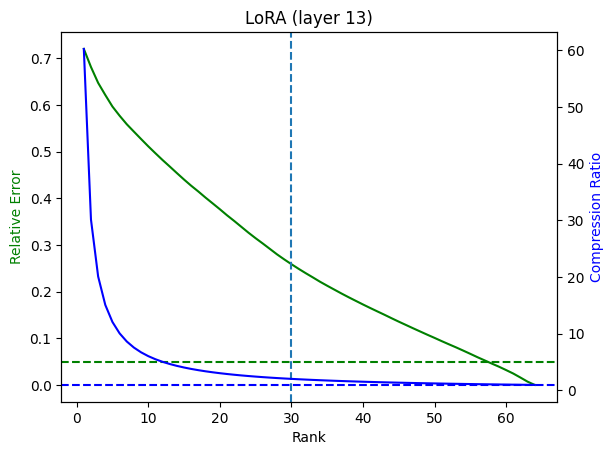

 88%|████████▊ | 14/16 [00:02<00:00,  7.00it/s]

Intercept found at rank  30
Error at intercept:  0.26472359895706177


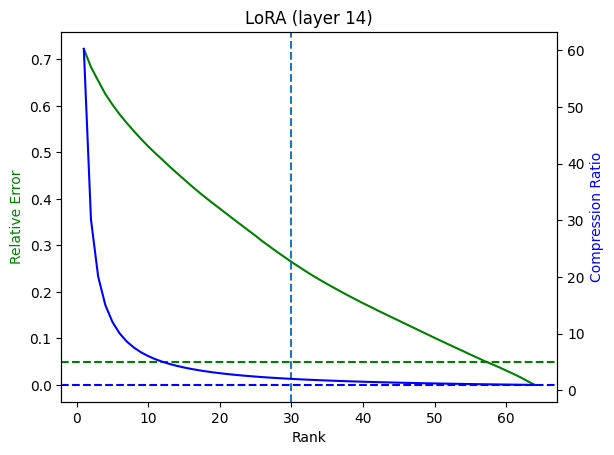

 94%|█████████▍| 15/16 [00:02<00:00,  3.51it/s]

Intercept found at rank  30
Error at intercept:  0.2648158073425293


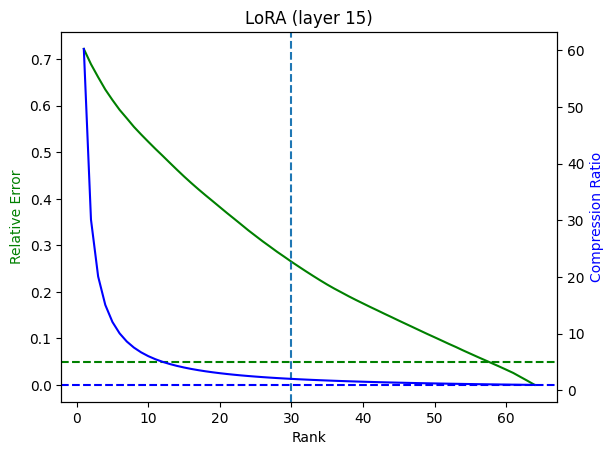

100%|██████████| 16/16 [00:02<00:00,  5.79it/s]


In [ ]:
import matplotlib.pyplot as plt

for layer in tqdm(range(keys.size(1))):
    for i, comp_ratio in enumerate([lora_keys_per_layer[layer][rank]['compression_ratio'] for rank in ranks]):
        if comp_ratio < 2.0:
            intercept = i
            print("Intercept found at rank ", intercept)
            print("Error at intercept: ", lora_keys_per_layer[layer][intercept]['relative_err'])
            break

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(
        ranks, 
        [lora_keys_per_layer[layer][rank]['relative_err'] for rank in ranks], 
        'g-', label='Relative Error'
    )
    ax2.plot(
        ranks, 
        [lora_keys_per_layer[layer][rank]['compression_ratio'] for rank in ranks], 
        'b-',
        label='Compression Ratio'
    )
    ax1.set_xlabel('Rank')
    ax1.set_ylabel('Relative Error', color='g')
    # make horizontal line at 0.05
    ax1.axhline(y=0.05, color='g', linestyle='--')
    ax1.axvline(x=intercept, linestyle='--')
    ax2.set_ylabel('Compression Ratio', color='b')
    # make horizontal line at 1.0
    ax2.axhline(y=1.0, color='b', linestyle='--')
    plt.title(f'LoRA (layer {layer})')
    plt.show()